In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/ecommerce_data.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
reference_date = df['order_date'].max() + pd.Timedelta(days=1)
print('Data Loaded | Reference Date:', reference_date.date())

Data Loaded | Reference Date: 2024-12-28


In [3]:
# =============================================
# BUILD RFM TABLE
# =============================================
rfm = df.groupby('customer_id').agg(
    Recency   = ('order_date', lambda x: (reference_date - x.max()).days),
    Frequency = ('order_id',   'count'),
    Monetary  = ('revenue',    'sum')
).reset_index()

print('RFM Table (first 10 rows):')
print(rfm.head(10))
print('\nRFM Statistics:')
print(rfm[['Recency','Frequency','Monetary']].describe())

RFM Table (first 10 rows):
  customer_id  Recency  Frequency  Monetary
0        C001       50          5     68795
1        C002      289          3      4895
2        C003      264          3     27996
3        C004      228          3      9195
4        C005      201          3      4696
5        C006      302          2     26996
6        C007      295          2     13997
7        C008      283          2      7396
8        C009      277          2      5497
9        C010      271          2     46499

RFM Statistics:
          Recency  Frequency       Monetary
count   49.000000  49.000000      49.000000
mean   139.326531   2.040816   29023.857143
std     94.342547   0.610982   27267.849061
min      1.000000   1.000000    1499.000000
25%     64.000000   2.000000    7396.000000
50%    132.000000   2.000000   16999.000000
75%    222.000000   2.000000   47999.000000
max    302.000000   5.000000  107000.000000


In [5]:
# =============================================
# RFM SCORING (1-5 scale)
# =============================================
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1], duplicates='drop')
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5], duplicates='drop')

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['Total_Score'] = rfm[['R_Score','F_Score','M_Score']].astype(int).sum(axis=1)

# Segment Labels
def segment_customer(score):
    if score >= 13:  return 'Champions'
    elif score >= 11: return 'Loyal Customers'
    elif score >= 9:  return 'Potential Loyalists'
    elif score >= 7:  return 'New Customers'
    elif score >= 5:  return 'At Risk'
    else:             return 'Lost Customers'

rfm['Segment'] = rfm['Total_Score'].apply(segment_customer)

print('\nCustomer Segments:')
print(rfm['Segment'].value_counts())


Customer Segments:
Segment
Potential Loyalists    16
New Customers           9
At Risk                 9
Champions               7
Loyal Customers         6
Lost Customers          2
Name: count, dtype: int64


In [7]:
import os

os.makedirs('dashboard', exist_ok=True)
os.makedirs('data', exist_ok=True)

print("Folders created:", os.listdir())

Folders created: ['.config', 'dashboard', 'data', 'ecommerce_data.csv', 'sample_data']


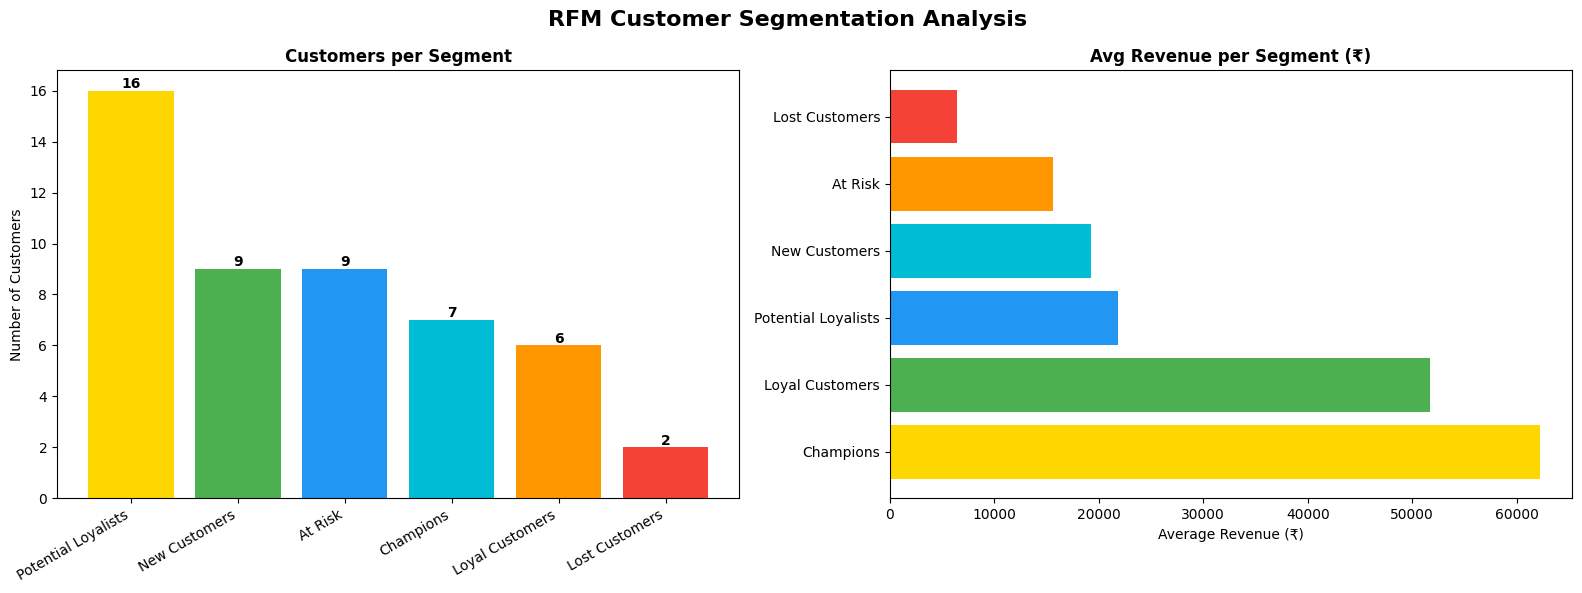

RFM Segmentation saved!


In [8]:
# =============================================
# VISUALIZE RFM SEGMENTS
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM Customer Segmentation Analysis', fontsize=16, fontweight='bold')

# Plot 1: Segment Count
seg_counts = rfm['Segment'].value_counts()
colors = ['#FFD700','#4CAF50','#2196F3','#00BCD4','#FF9800','#F44336']
axes[0].bar(range(len(seg_counts)), seg_counts.values, color=colors[:len(seg_counts)])
axes[0].set_xticks(range(len(seg_counts)))
axes[0].set_xticklabels(seg_counts.index, rotation=30, ha='right')
axes[0].set_title('Customers per Segment', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Plot 2: Avg Monetary by Segment
seg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
axes[1].barh(seg_monetary.index, seg_monetary.values, color=colors[:len(seg_monetary)])
axes[1].set_title('Avg Revenue per Segment (₹)', fontweight='bold')
axes[1].set_xlabel('Average Revenue (₹)')

plt.tight_layout()
plt.savefig('dashboard/rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

# Save RFM results
rfm.to_csv('data/rfm_results.csv', index=False)
print('RFM Segmentation saved!')

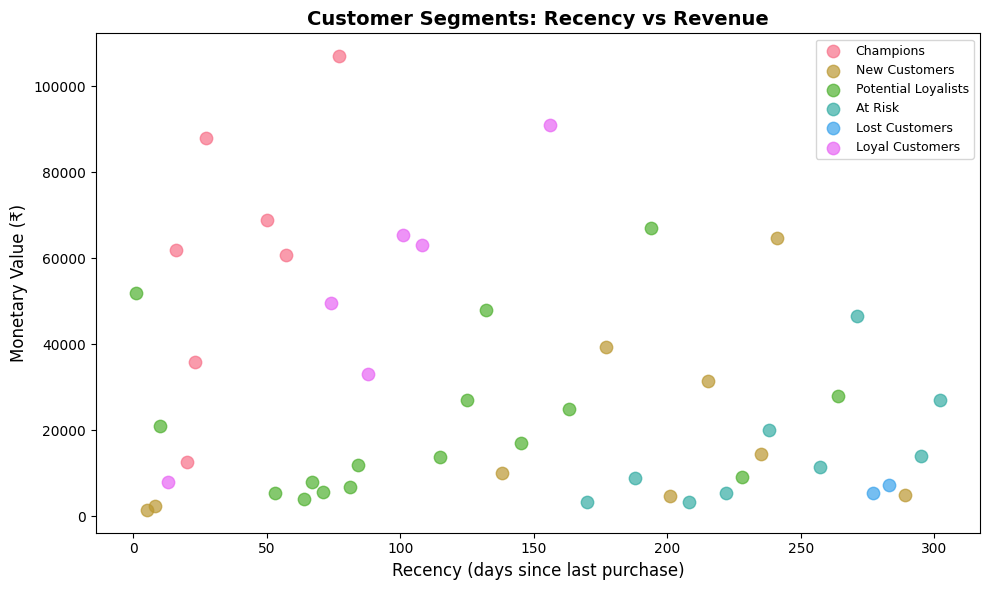

RFM Scatter plot saved!


In [9]:
# =============================================
# SCATTER PLOT: Recency vs Monetary
# =============================================
fig, ax = plt.subplots(figsize=(10, 6))
segments = rfm['Segment'].unique()
palette  = dict(zip(segments, sns.color_palette('husl', len(segments))))

for seg in segments:
    subset = rfm[rfm['Segment'] == seg]
    ax.scatter(subset['Recency'], subset['Monetary'], label=seg,
               alpha=0.7, s=80, color=palette[seg])

ax.set_xlabel('Recency (days since last purchase)', fontsize=12)
ax.set_ylabel('Monetary Value (₹)', fontsize=12)
ax.set_title('Customer Segments: Recency vs Revenue', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('dashboard/rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('RFM Scatter plot saved!')